# 🚀 Day 3: Logistic Regression & Classification Metrics

---

## 🎯 Learning Objectives
- ✅ Train a logistic regression classifier and obtain class probabilities  
- ✅ Explain why accuracy alone is misleading on imbalanced data  
- ✅ Read a confusion matrix and compute precision, recall, F1, and AUC-ROC  
- ✅ Decide whether precision or recall matters more for churn prediction  

---

## 📚 Key Topics
- Logistic regression: weighted sum + sigmoid → probability  
- Why accuracy is misleading on imbalanced data  
- The confusion matrix: TP, FP, FN, TN  
- Precision, recall, F1, and their trade-off  
- AUC-ROC  

---

## 3.1 From Regression to Classification
Logistic regression predicts a **category**, not a number.  
It computes a weighted sum of features, then passes it through the **sigmoid function**, which squashes values into probabilities between 0 and 1.  
If the probability > 0.5, it predicts the positive class (churn).

In [5]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.isnull().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
y = df["Churn"]


In [6]:
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)   # class probabilities


## 3.2 Why Accuracy Alone Is Misleading

Accuracy = fraction of correct predictions.  
But if 95% of customers don’t churn, a model that always predicts **“No Churn”** scores 95% accuracy while being **useless**.  
This is why classification needs richer metrics like **precision, recall, F1-score, and AUC-ROC**.


In [7]:
from sklearn.metrics import accuracy_score

baseline_pred = [0] * len(y_test)  # predict "No Churn" for all
baseline_acc = accuracy_score(y_test, baseline_pred)
model_acc = accuracy_score(y_test, predictions)

print("Baseline Accuracy (always No Churn):", baseline_acc)
print("Model Accuracy:", model_acc)

Baseline Accuracy (always No Churn): 0.7352732434350603
Model Accuracy: 0.8218594748048261


## 3.3 The Confusion Matrix
The confusion matrix breaks predictions into four categories:
|  | Predicted Positive | Predicted Negative |
| --- | --- | --- |
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[934 102]
 [149 224]]


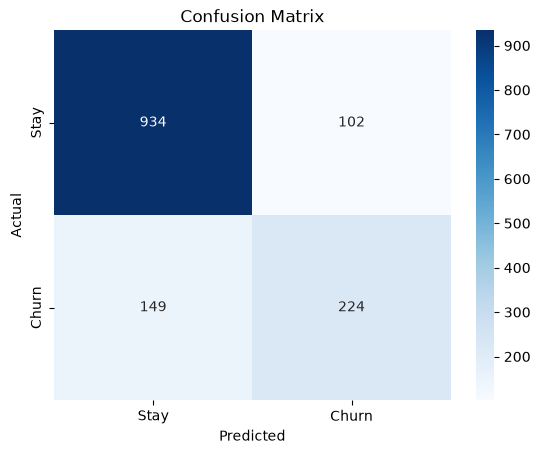

In [10]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay","Churn"], yticklabels=["Stay","Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()




## 3.4 Precision, Recall & F1
Precision = TP / (TP + FP) → “Of everything predicted churn, how much was right”

Recall = TP / (TP + FN) → “Of all actual churners, how many did I catch?”

F1-score = harmonic mean of precision & recall → balanced score.

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



💡 Trade-off:

For churn, recall often matters more (catch as many churners as possible).

But if retention campaigns are expensive, precision matters (don’t waste effort on false alarms).

## 3.5 AUC-ROC
The ROC curve plots the trade-off between catching positives and raising false alarms across thresholds.
AUC summarizes it:

- 0.5 = random guessing

- 1.0 = perfect classifier

AUC-ROC: 0.8625138447524505


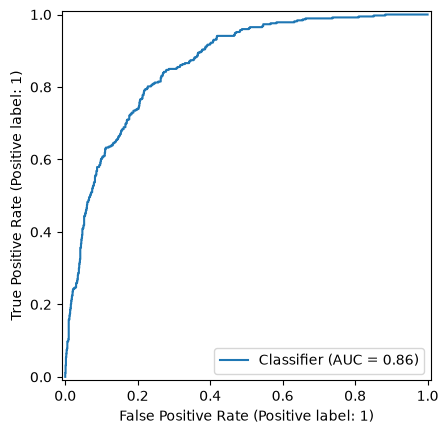

In [12]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print("AUC-ROC:", roc_auc_score(y_test, probabilities[:,1]))

RocCurveDisplay.from_predictions(y_test, probabilities[:,1])
